# 🎯 Project 3: AI Recommendation Logic
## DecodeLabs AI Internship | Batch 2026
### Tech Stack Recommender — Content-Based Filtering Engine

**Architecture:** IPO Framework
- INPUT  → User Skills (min 3) → TF-IDF Vector
- PROCESS → Cosine Similarity against all Job Role vectors
- OUTPUT → Top-N Ranked Career Recommendations + Skill Gap Analysis

**Algorithm:** Content-Based Filtering

**Similarity Metric:** Cosine Similarity (industry standard)

**Feature Extraction:** TF-IDF Weighting

**Developer:** Kashaf Kamran

**Dataset:** 15 Tech Job Roles × 40+ Unique Skills

In [1]:
import numpy  as np
import pandas as pd

# SKLEARN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise         import cosine_similarity

# VISUALIZATION
import matplotlib.pyplot    as plt
import matplotlib.patches   as mpatches
import seaborn              as sns

# DISPLAY SETTINGS
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"]     = 120

# DISPLAY ALL DATAFRAME ROWS
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows",     50)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# THE KNOWLEDGE BASE: JOB ROLES DATASET

# NOTE:
#   In production this would be loaded from raw_skills.csv.
#   We build it inline here so the notebook is self-contained
#   and requires zero file uploads to run.

job_roles_data = {

    # DATA & AI ROLES
    "Data Scientist": {
        "skills": "python sql machine_learning data_analysis statistics "
                  "tensorflow pandas numpy data_visualization jupyter "
                  "deep_learning regression classification",
        "description": "Extracts insights from data using ML models and statistical analysis.",
        "avg_salary"  : "PKR 150,000–250,000/month",
        "category"    : "Data & AI",
    },
    "Machine Learning Engineer": {
        "skills": "python machine_learning deep_learning tensorflow pytorch "
                  "algorithms data_structures api_development model_deployment "
                  "docker kubernetes mlops numpy pandas",
        "description": "Builds, trains, and deploys ML models into production systems.",
        "avg_salary"  : "PKR 180,000–300,000/month",
        "category"    : "Data & AI",
    },
    "AI Research Scientist": {
        "skills": "python deep_learning tensorflow pytorch research mathematics "
                  "statistics algorithms neural_networks nlp computer_vision "
                  "reinforcement_learning publications",
        "description": "Conducts research to advance AI/ML theory and applications.",
        "avg_salary"  : "PKR 200,000–400,000/month",
        "category"    : "Data & AI",
    },
    "Data Analyst": {
        "skills": "sql excel data_analysis statistics data_visualization "
                  "python pandas tableau power_bi reporting dashboards "
                  "business_intelligence communication",
        "description": "Analyzes datasets to produce actionable business insights.",
        "avg_salary"  : "PKR 80,000–150,000/month",
        "category"    : "Data & AI",
    },
    "Data Engineer": {
        "skills": "python sql spark hadoop etl data_pipelines airflow "
                  "aws cloud_computing databases kafka data_warehousing "
                  "scala docker",
        "description": "Builds infrastructure and pipelines to collect and process data.",
        "avg_salary"  : "PKR 130,000–230,000/month",
        "category"    : "Data & AI",
    },

    # DEVELOPMENT ROLES
    "Backend Developer": {
        "skills": "python java nodejs sql apis rest_api databases "
                  "docker git authentication server_management "
                  "microservices postgresql mongodb",
        "description": "Builds server-side logic, APIs, and database integrations.",
        "avg_salary"  : "PKR 100,000–200,000/month",
        "category"    : "Development",
    },
    "Frontend Developer": {
        "skills": "javascript html css react vuejs typescript "
                  "ui_design responsive_design git figma "
                  "web_performance accessibility rest_api",
        "description": "Builds user interfaces and client-side web experiences.",
        "avg_salary"  : "PKR 80,000–160,000/month",
        "category"    : "Development",
    },
    "Full Stack Developer": {
        "skills": "javascript python html css react nodejs sql "
                  "rest_api git docker databases mongodb "
                  "typescript authentication deployment",
        "description": "Handles both frontend and backend development end-to-end.",
        "avg_salary"  : "PKR 120,000–220,000/month",
        "category"    : "Development",
    },
    "Mobile App Developer": {
        "skills": "flutter dart react_native javascript java kotlin "
                  "ios android api_development git firebase "
                  "ui_design app_deployment",
        "description": "Builds native and cross-platform mobile applications.",
        "avg_salary"  : "PKR 100,000–190,000/month",
        "category"    : "Development",
    },

    # INFRASTRUCTURE ROLES
    "DevOps Engineer": {
        "skills": "docker kubernetes aws linux ci_cd git jenkins "
                  "terraform automation shell_scripting monitoring "
                  "cloud_computing networking security",
        "description": "Bridges development and operations through automation and cloud infrastructure.",
        "avg_salary"  : "PKR 130,000–250,000/month",
        "category"    : "Infrastructure",
    },
    "Cloud Architect": {
        "skills": "aws azure gcp cloud_computing networking security "
                  "docker kubernetes terraform infrastructure "
                  "cost_optimization scalability disaster_recovery",
        "description": "Designs and oversees cloud infrastructure and migration strategies.",
        "avg_salary"  : "PKR 200,000–350,000/month",
        "category"    : "Infrastructure",
    },
    "Cybersecurity Analyst": {
        "skills": "networking security penetration_testing linux "
                  "firewalls encryption vulnerability_assessment "
                  "incident_response compliance ethical_hacking siem",
        "description": "Protects systems and networks from cyber threats and breaches.",
        "avg_salary"  : "PKR 120,000–220,000/month",
        "category"    : "Infrastructure",
    },

    # SPECIALIZED ROLES
    "NLP Engineer": {
        "skills": "python nlp machine_learning deep_learning transformers "
                  "bert tensorflow pytorch text_processing spacy "
                  "sentiment_analysis named_entity_recognition chatbots",
        "description": "Builds systems that process and understand human language.",
        "avg_salary"  : "PKR 150,000–280,000/month",
        "category"    : "Specialized AI",
    },
    "Computer Vision Engineer": {
        "skills": "python computer_vision deep_learning tensorflow pytorch "
                  "opencv image_processing convolutional_networks "
                  "object_detection image_classification cuda",
        "description": "Builds systems that interpret and analyze visual data.",
        "avg_salary"  : "PKR 150,000–280,000/month",
        "category"    : "Specialized AI",
    },
    "MLOps Engineer": {
        "skills": "python machine_learning docker kubernetes mlops "
                  "model_deployment aws ci_cd monitoring airflow "
                  "data_pipelines tensorflow pytorch git automation",
        "description": "Manages ML model lifecycle from development to production monitoring.",
        "avg_salary"  : "PKR 160,000–290,000/month",
        "category"    : "Infrastructure",
    },
}

# CONVERT TO DATAFRAME
df_roles = pd.DataFrame.from_dict(job_roles_data, orient="index")
df_roles.index.name = "Job Role"
df_roles = df_roles.reset_index()

print("=" * 60)
print("  KNOWLEDGE BASE LOADED")
print("=" * 60)
print(f"\n  Total Job Roles  : {len(df_roles)}")
print(f"  Categories       : {df_roles['category'].unique().tolist()}")
print(f"\n  Roles by Category:")
print(df_roles.groupby("category")["Job Role"].apply(list).to_string())

  KNOWLEDGE BASE LOADED

  Total Job Roles  : 15
  Categories       : ['Data & AI', 'Development', 'Infrastructure', 'Specialized AI']

  Roles by Category:
category
Data & AI         [Data Scientist, Machine Learning Engineer, AI Research Scientist, Data Analyst, Data Engineer]
Development                   [Backend Developer, Frontend Developer, Full Stack Developer, Mobile App Developer]
Infrastructure                          [DevOps Engineer, Cloud Architect, Cybersecurity Analyst, MLOps Engineer]
Specialized AI                                                           [NLP Engineer, Computer Vision Engineer]


In [3]:
#  PHASE 1 (INPUT): BUILD TF-IDF MATRIX

#  BUILD THE VECTORIZER
tfidf_vectorizer = TfidfVectorizer(
    tokenizer       = lambda x: x.split(),   # Split on spaces
    lowercase       = True,
    token_pattern   = None,                  # Use our custom tokenizer
)

# FIT ON ROLE DATA & TRANSFORM
tfidf_matrix = tfidf_vectorizer.fit_transform(df_roles["skills"])

# EXTRACT VOCABULARY
vocabulary = tfidf_vectorizer.get_feature_names_out()

# DISPLAY RESULTS
print("=" * 60)
print("  TF-IDF MATRIX BUILT")
print("=" * 60)
print(f"\n  Roles (rows)          : {tfidf_matrix.shape[0]}")
print(f"  Unique Skills (cols)  : {tfidf_matrix.shape[1]}")
print(f"\n  Complete Skill Vocabulary ({len(vocabulary)} skills):")

vocab_list = sorted(vocabulary)
for i in range(0, len(vocab_list), 5):
    row = vocab_list[i:i+5]
    print(f"    {', '.join(row)}")

print(f"\nTF-IDF matrix ready. Shape: {tfidf_matrix.shape}")

  TF-IDF MATRIX BUILT

  Roles (rows)          : 15
  Unique Skills (cols)  : 112

  Complete Skill Vocabulary (112 skills):
    accessibility, airflow, algorithms, android, api_development
    apis, app_deployment, authentication, automation, aws
    azure, bert, business_intelligence, chatbots, ci_cd
    classification, cloud_computing, communication, compliance, computer_vision
    convolutional_networks, cost_optimization, css, cuda, dart
    dashboards, data_analysis, data_pipelines, data_structures, data_visualization
    data_warehousing, databases, deep_learning, deployment, disaster_recovery
    docker, encryption, ethical_hacking, etl, excel
    figma, firebase, firewalls, flutter, gcp
    git, hadoop, html, image_classification, image_processing
    incident_response, infrastructure, ios, java, javascript
    jenkins, jupyter, kafka, kotlin, kubernetes
    linux, machine_learning, mathematics, microservices, mlops
    model_deployment, mongodb, monitoring, named_entity_recog

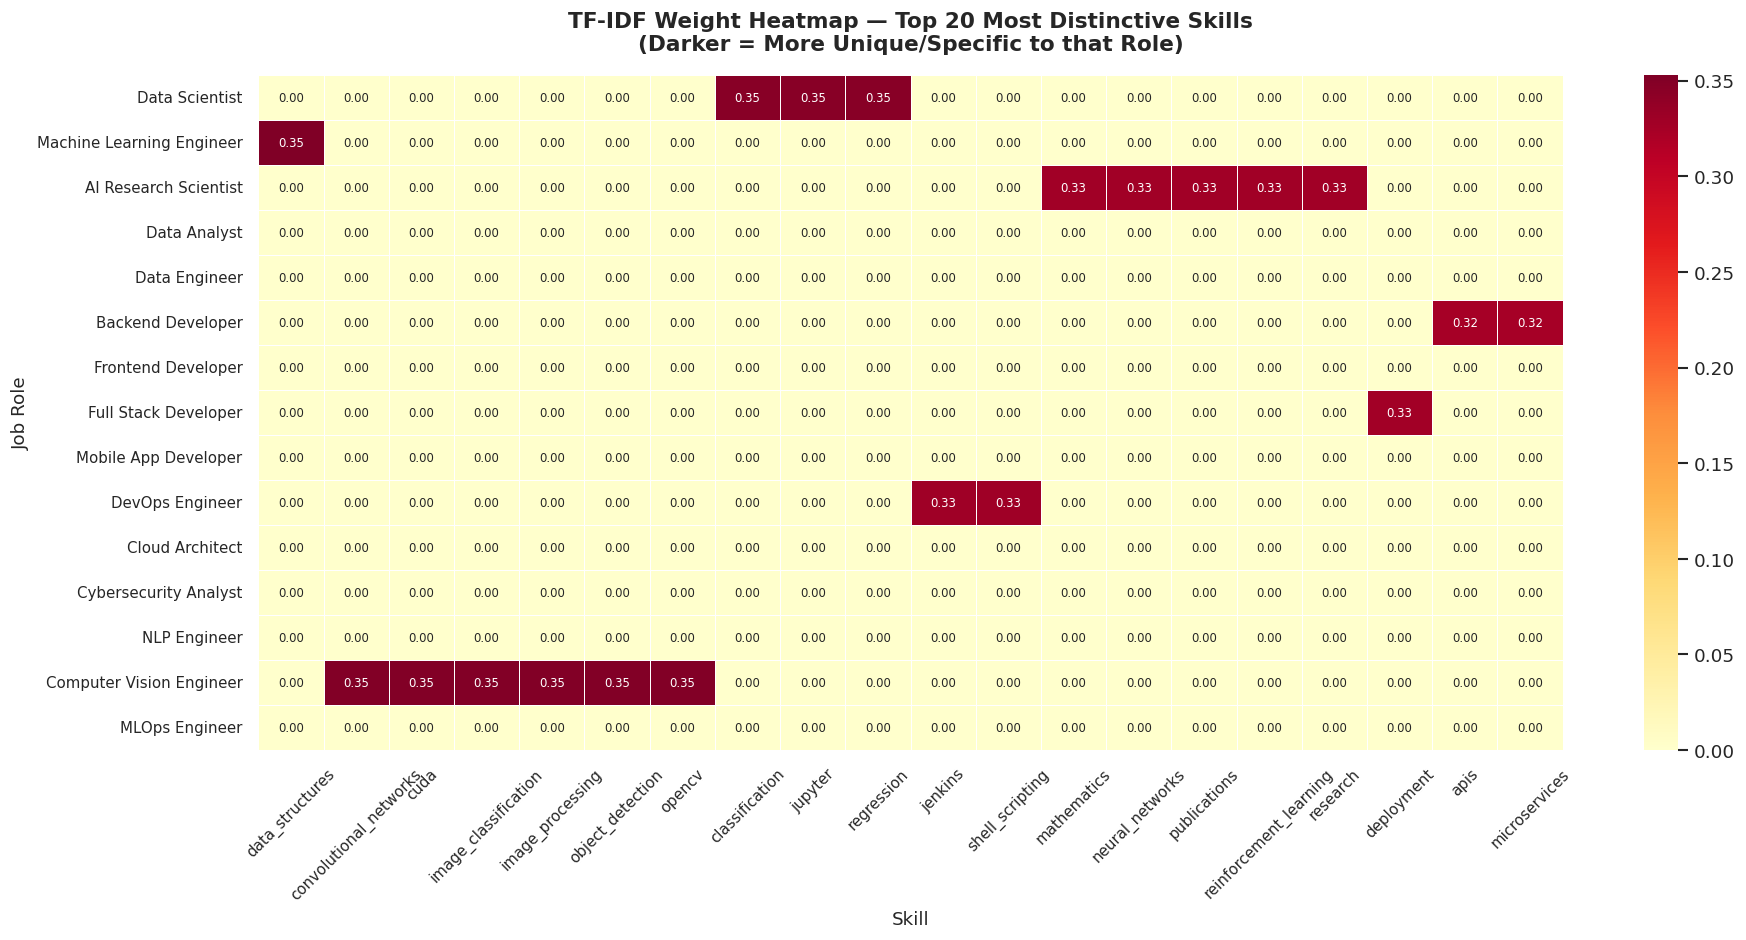


 KEY OBSERVATION:
   Skills like 'python' appear in many roles → lower TF-IDF weight
   Skills like 'kubernetes', 'nlp' are specific → higher TF-IDF weight
   This is TF-IDF's penalize-generic, reward-specific behavior.


In [4]:
# VISUALIZATION 1: TF-IDF WEIGHT HEATMAP


# Convert sparse matrix to dense for visualization
tfidf_dense = pd.DataFrame(
    tfidf_matrix.toarray(),
    index   = df_roles["Job Role"],
    columns = vocabulary,
)

# Select top 20 most distinctive skills for readability
top_skills = tfidf_dense.max(axis=0).nlargest(20).index
tfidf_top  = tfidf_dense[top_skills]

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    tfidf_top,
    cmap        = "YlOrRd",
    linewidths  = 0.3,
    linecolor   = "white",
    annot       = True,
    fmt         = ".2f",
    annot_kws   = {"size": 7},
    ax          = ax,
)

ax.set_title(
    "TF-IDF Weight Heatmap — Top 20 Most Distinctive Skills\n"
    "(Darker = More Unique/Specific to that Role)",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Skill",     fontsize=11)
ax.set_ylabel("Job Role",  fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("tfidf_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n KEY OBSERVATION:")
print("   Skills like 'python' appear in many roles → lower TF-IDF weight")
print("   Skills like 'kubernetes', 'nlp' are specific → higher TF-IDF weight")
print("   This is TF-IDF's penalize-generic, reward-specific behavior.")

In [5]:
# THE CORE ENGINE: 4-STEP PIPELINE


def get_recommendations(
    user_skills : list,
    top_n       : int  = 5,
    min_score   : float = 0.0,
) -> pd.DataFrame:
    """
    Core recommendation engine.

    Args:
        user_skills : List of skill strings (min 3 recommended)
        top_n       : Number of top results to return
        min_score   : Minimum similarity threshold (0.0 to 1.0)

    Returns:
        DataFrame with ranked recommendations + metadata
    """

    # COLD START HANDLER
    if not user_skills or len(user_skills) == 0:
        print("⚠  No skills provided — Cold Start detected.")
        print("   Returning trending roles as fallback...\n")
        trending = df_roles.head(top_n).copy()
        trending["similarity_score"] = "N/A (Trending)"
        trending["match_pct"]        = "N/A"
        return trending[["Job Role", "category", "description",
                          "avg_salary", "similarity_score"]]

    # STEP 1: INGESTION
    cleaned_skills = [s.strip().lower().replace(" ", "_")
                      for s in user_skills]
    user_skill_string = " ".join(cleaned_skills)

    # Transform user profile using the SAME fitted vectorizer
    user_vector = tfidf_vectorizer.transform([user_skill_string])

    # STEP 2: SCORING
    similarity_scores = cosine_similarity(user_vector, tfidf_matrix)
    scores_flat       = similarity_scores.flatten()

    # STEP 3: SORTING
    sorted_indices = np.argsort(scores_flat)[::-1]

    # STEP 4: FILTERING (Top-N)
    results = []
    for idx in sorted_indices:
        score = scores_flat[idx]
        if score >= min_score:
            role_data = df_roles.iloc[idx].to_dict()
            role_data["similarity_score"] = round(float(score), 4)
            role_data["match_pct"]        = f"{round(float(score)*100, 1)}%"
            results.append(role_data)
        if len(results) == top_n:
            break

    results_df = pd.DataFrame(results)

    return results_df[[
        "Job Role", "category", "similarity_score",
        "match_pct", "description", "avg_salary", "skills"
    ]]


# VERIFY ENGINE WORKS
print("=" * 60)
print("  RECOMMENDATION ENGINE — READY")
print("=" * 60)
print("\n  Function: get_recommendations(user_skills, top_n, min_score)")
print("  Pipeline: Ingestion → Scoring → Sorting → Filtering")
print("  Metric  : Cosine Similarity (0 = no match, 1 = perfect)")
print("\n Engine loaded. Proceed to Cell 7 to run recommendations.")

  RECOMMENDATION ENGINE — READY

  Function: get_recommendations(user_skills, top_n, min_score)
  Pipeline: Ingestion → Scoring → Sorting → Filtering
  Metric  : Cosine Similarity (0 = no match, 1 = perfect)

 Engine loaded. Proceed to Cell 7 to run recommendations.


In [6]:
# SKILL GAP ANALYZER

def analyze_skill_gap(user_skills: list, target_role: str) -> dict:
    """
    Compares user's skills against a target job role.
    Returns matched skills, missing skills, and match percentage.
    """
    # Get role skills
    role_row    = df_roles[df_roles["Job Role"] == target_role]
    if role_row.empty:
        return {"error": f"Role '{target_role}' not found."}

    role_skills_raw = role_row["skills"].values[0]
    role_skills_set = set(role_skills_raw.split())

    # Clean user skills to match vocabulary format
    user_skills_clean = set(
        s.strip().lower().replace(" ", "_") for s in user_skills
    )

    matched  = user_skills_clean & role_skills_set
    missing  = role_skills_set - user_skills_clean
    extra    = user_skills_clean - role_skills_set
    pct      = len(matched) / len(role_skills_set) * 100

    return {
        "role"          : target_role,
        "role_skills"   : role_skills_set,
        "user_skills"   : user_skills_clean,
        "matched"       : matched,
        "missing"       : missing,
        "extra_skills"  : extra,
        "match_pct"     : round(pct, 1),
        "total_required": len(role_skills_set),
        "skills_you_have": len(matched),
    }


def display_skill_gap(gap: dict):
    """Prints a formatted skill gap report."""
    print("=" * 60)
    print(f"  SKILL GAP ANALYSIS: {gap['role']}")
    print("=" * 60)
    print(f"\n  Skills Required   : {gap['total_required']}")
    print(f"  Skills You Have   : {gap['skills_you_have']}")
    print(f"  Coverage          : {gap['match_pct']}%")

    print(f"\n  MATCHED SKILLS ({len(gap['matched'])}):")
    for s in sorted(gap["matched"]):
        print(f"     • {s.replace('_', ' ').title()}")

    print(f"\n  SKILLS TO LEARN ({len(gap['missing'])}):")
    for s in sorted(gap["missing"]):
        print(f"     • {s.replace('_', ' ').title()}")

    if gap["extra_skills"]:
        print(f"\n  BONUS SKILLS YOU HAVE ({len(gap['extra_skills'])}):")
        print(f"     (Not required for this role but valuable)")
        for s in sorted(gap["extra_skills"]):
            print(f"     • {s.replace('_', ' ').title()}")
    print("=" * 60)


print(" Skill Gap Analyzer loaded.")

 Skill Gap Analyzer loaded.


In [7]:
# VISUALIZATION ENGINE

def visualize_recommendations(results_df: pd.DataFrame,
                               user_skills: list,
                               gap: dict = None):
    """Generates recommendation charts."""

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # CHART 1: SIMILARITY SCORE BAR CHART
    ax1 = axes[0]

    roles  = results_df["Job Role"].tolist()
    scores = results_df["similarity_score"].tolist()
    cats   = results_df["category"].tolist()

    # Color by category
    cat_colors = {
        "Data & AI"      : "#E74C3C",
        "Development"    : "#3498DB",
        "Infrastructure" : "#2ECC71",
        "Specialized AI" : "#9B59B6",
    }
    colors = [cat_colors.get(c, "#95A5A6") for c in cats]

    bars = ax1.barh(
        roles[::-1], scores[::-1],
        color=[cat_colors.get(c, "#95A5A6") for c in cats[::-1]],
        height=0.6, alpha=0.85, edgecolor="white", linewidth=0.5
    )

    # Add score labels on bars
    for bar, score in zip(bars, scores[::-1]):
        ax1.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{score*100:.1f}%",
            va="center", fontsize=10, fontweight="bold"
        )

    ax1.set_title(
        f"Top {len(results_df)} Career Recommendations\n"
        f"Input Skills: {', '.join(user_skills[:4])}{'...' if len(user_skills)>4 else ''}",
        fontsize=12, fontweight="bold", pad=12
    )
    ax1.set_xlabel("Cosine Similarity Score", fontsize=11)
    ax1.set_xlim(0, min(1.0, max(scores) * 1.25))

    # Legend
    legend_patches = [
        mpatches.Patch(color=v, label=k)
        for k, v in cat_colors.items()
    ]
    ax1.legend(handles=legend_patches, loc="lower right",
               fontsize=9, title="Category")
    ax1.grid(axis="x", alpha=0.3)
    ax1.spines[["top","right"]].set_visible(False)

    # CHART 2: SKILL GAP DONUT CHART
    ax2 = axes[1]

    if gap and "matched" in gap:
        matched_n = len(gap["matched"])
        missing_n = len(gap["missing"])

        sizes  = [matched_n, missing_n]
        labels = [f"Skills You Have\n({matched_n})",
                  f"Skills to Learn\n({missing_n})"]
        colors_pie = ["#2ECC71", "#E74C3C"]
        explode    = (0.05, 0)

        wedges, texts, autotexts = ax2.pie(
            sizes,
            labels    = labels,
            colors    = colors_pie,
            explode   = explode,
            autopct   = "%1.1f%%",
            startangle= 90,
            pctdistance= 0.75,
            wedgeprops = {"linewidth": 2, "edgecolor": "white"},
        )

        for t in autotexts:
            t.set_fontsize(12)
            t.set_fontweight("bold")

        # Donut hole
        centre_circle = plt.Circle((0, 0), 0.55, fc="white")
        ax2.add_patch(centre_circle)

        ax2.text(
            0, 0, f"{gap['match_pct']}%\nMatch",
            ha="center", va="center",
            fontsize=16, fontweight="bold", color="#2C3E50"
        )
        ax2.set_title(
            f"Skill Gap Analysis\nTop Match: {gap['role']}",
            fontsize=12, fontweight="bold", pad=12
        )
    else:
        ax2.text(0.5, 0.5, "Run skill gap\nanalysis first",
                 ha="center", va="center", fontsize=14,
                 transform=ax2.transAxes)
        ax2.axis("off")

    plt.tight_layout(pad=3)
    plt.savefig("recommendations.png", dpi=120, bbox_inches="tight")
    plt.show()


print(" Visualization engine loaded.")

 Visualization engine loaded.


  🚀 RUNNING RECOMMENDATION ENGINE

  Your Skills  : ['python', 'machine_learning', 'sql', 'deep_learning', 'tensorflow', 'data_analysis']
  Requesting   : Top 5 matches
  Algorithm    : TF-IDF + Cosine Similarity
  Pipeline     : Ingestion → Scoring → Sorting → Filtering

  📋 TOP RECOMMENDATIONS

  #1  Data Scientist  [Data & AI]
      Match  : [███████████░░░░░░░░░] 56.1%
      Salary : PKR 150,000–250,000/month
      About  : Extracts insights from data using ML models and statistical analysis.

  #2  Machine Learning Engineer  [Data & AI]
      Match  : [██████░░░░░░░░░░░░░░] 31.7%
      Salary : PKR 180,000–300,000/month
      About  : Builds, trains, and deploys ML models into production systems.

  #3  NLP Engineer  [Specialized AI]
      Match  : [█████░░░░░░░░░░░░░░░] 29.0%
      Salary : PKR 150,000–280,000/month
      About  : Builds systems that process and understand human language.

  #4  Data Analyst  [Data & AI]
      Match  : [█████░░░░░░░░░░░░░░░] 26.3%
      Salary : 

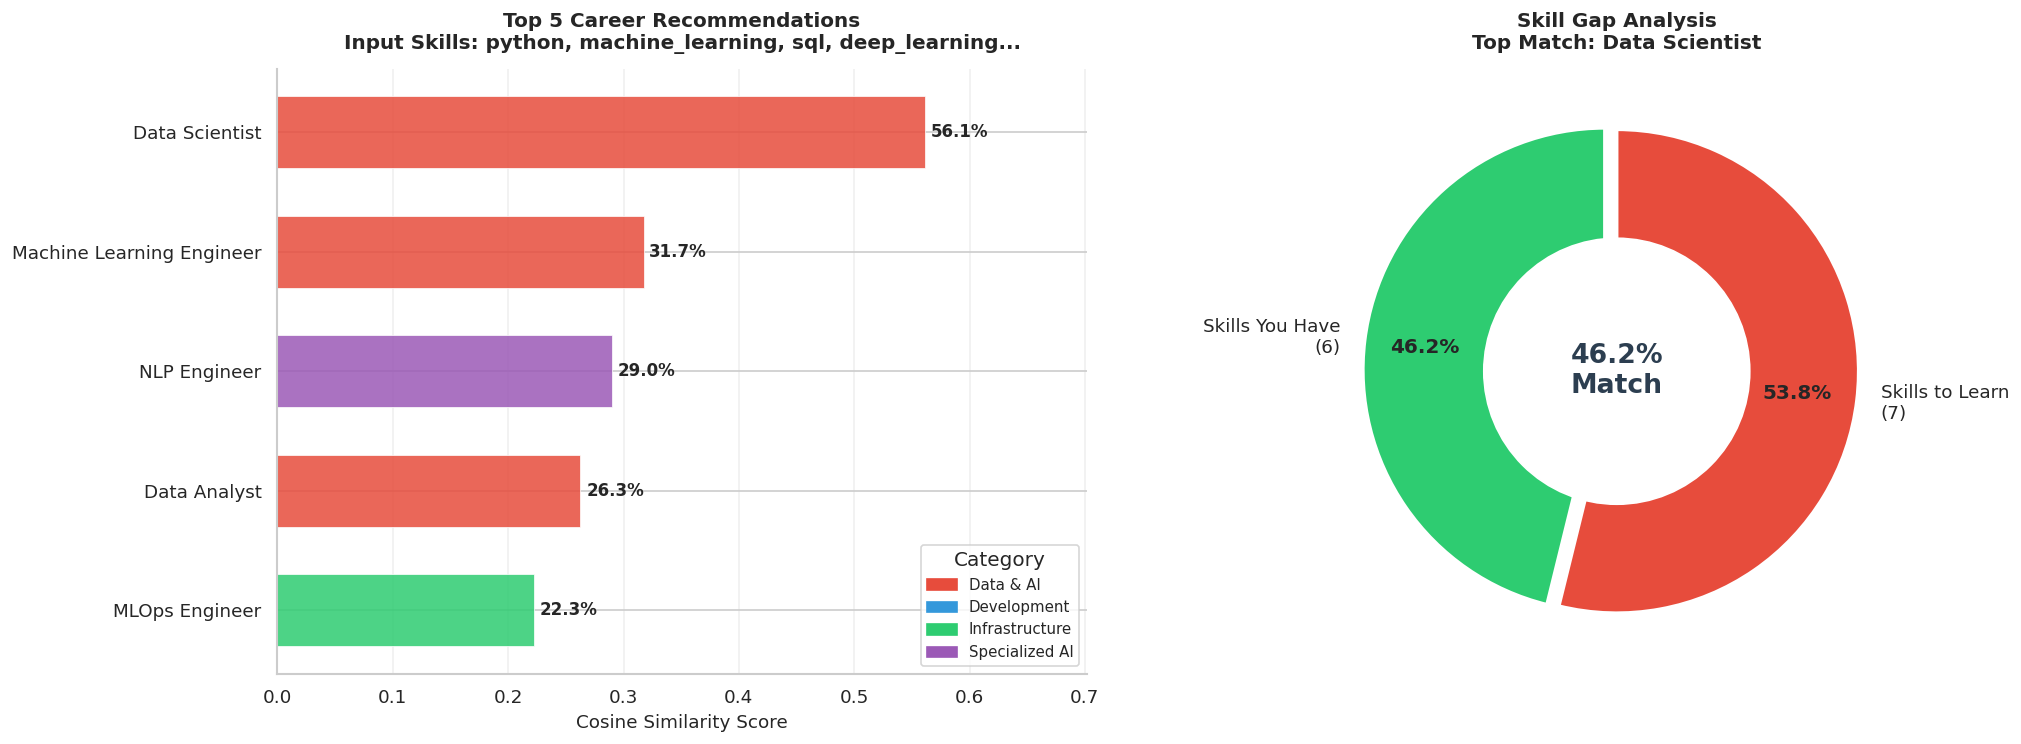

In [8]:
# YOUR FIRST RECOMMENDATION RUN

# CHANGE THE SKILLS LIST BELOW TO YOUR OWN SKILLS
#
# AVAILABLE SKILLS (copy exactly from this list):
#   python, sql, machine_learning, deep_learning, tensorflow,
#   pytorch, data_analysis, statistics, javascript, html, css,
#   react, nodejs, docker, kubernetes, aws, azure, gcp, linux,
#   git, java, kotlin, flutter, dart, security, networking,
#   nlp, computer_vision, opencv, spark, hadoop, etl, airflow,
#   mongodb, postgresql, rest_api, typescript, figma, excel,
#   tableau, power_bi, mlops, model_deployment, ci_cd, terraform

# ENTER YOUR SKILLS HERE
MY_SKILLS = [
    "python",
    "machine_learning",
    "sql",
    "deep_learning",
    "tensorflow",
    "data_analysis",
]

TOP_N = 5   # How many recommendations to show

# RUN THE 4-STEP PIPELINE
print("=" * 60)
print("  🚀 RUNNING RECOMMENDATION ENGINE")
print("=" * 60)
print(f"\n  Your Skills  : {MY_SKILLS}")
print(f"  Requesting   : Top {TOP_N} matches")
print(f"  Algorithm    : TF-IDF + Cosine Similarity")
print(f"  Pipeline     : Ingestion → Scoring → Sorting → Filtering\n")

# Step 1-4: Get recommendations
results = get_recommendations(MY_SKILLS, top_n=TOP_N)

# DISPLAY RESULTS TABLE
print("=" * 60)
print("  📋 TOP RECOMMENDATIONS")
print("=" * 60)

for rank, (_, row) in enumerate(results.iterrows(), 1):
    bar_len   = int(row["similarity_score"] * 20)
    bar_empty = 20 - bar_len
    bar       = "█" * bar_len + "░" * bar_empty
    print(f"\n  #{rank}  {row['Job Role']}  [{row['category']}]")
    print(f"      Match  : [{bar}] {row['match_pct']}")
    print(f"      Salary : {row['avg_salary']}")
    print(f"      About  : {row['description']}")

# SKILL GAP FOR TOP MATCH
top_role = results.iloc[0]["Job Role"]
gap      = analyze_skill_gap(MY_SKILLS, top_role)
display_skill_gap(gap)

# VISUALIZE
visualize_recommendations(results, MY_SKILLS, gap)

In [10]:
# MULTI-PROFILE TESTING

test_profiles = {
    " Web Developer Profile": [
        "javascript", "html", "css", "react", "nodejs", "git"
    ],
    "  Cloud Engineer Profile": [
        "aws", "docker", "kubernetes", "linux", "terraform", "ci_cd"
    ],
    " Security Analyst Profile": [
        "networking", "security", "linux", "python", "ethical_hacking"
    ],
    " Mobile Developer Profile": [
        "flutter", "dart", "firebase", "git", "ui_design", "api_development"
    ],
}

for profile_name, skills in test_profiles.items():
    print("\n" + "=" * 60)
    print(f"  {profile_name}")
    print(f"  Skills: {skills}")
    print("=" * 60)

    recs = get_recommendations(skills, top_n=3)

    for rank, (_, row) in enumerate(recs.iterrows(), 1):
        print(f"  #{rank}  {row['Job Role']:<30} "
              f"[{row['match_pct']:>6}]  {row['category']}")

print("\n\n All 4 profiles returned DIFFERENT top recommendations.")
print(" This confirms the similarity engine is working correctly.")


   Web Developer Profile
  Skills: ['javascript', 'html', 'css', 'react', 'nodejs', 'git']
  #1  Full Stack Developer           [ 65.2%]  Development
  #2  Frontend Developer             [ 50.2%]  Development
  #3  Backend Developer              [ 18.0%]  Development

    Cloud Engineer Profile
  Skills: ['aws', 'docker', 'kubernetes', 'linux', 'terraform', 'ci_cd']
  #1  DevOps Engineer                [ 62.1%]  Infrastructure
  #2  MLOps Engineer                 [ 37.5%]  Infrastructure
  #3  Cloud Architect                [ 34.6%]  Infrastructure

   Security Analyst Profile
  Skills: ['networking', 'security', 'linux', 'python', 'ethical_hacking']
  #1  Cybersecurity Analyst          [ 52.7%]  Infrastructure
  #2  DevOps Engineer                [ 36.3%]  Infrastructure
  #3  Cloud Architect                [ 21.6%]  Infrastructure

   Mobile Developer Profile
  Skills: ['flutter', 'dart', 'firebase', 'git', 'ui_design', 'api_development']
  #1  Mobile App Developer           [ 65.8%

In [11]:
#  COLD START HANDLER TEST

print("=" * 60)
print("  COLD START TEST")
print("=" * 60)
print("\n  Simulating a brand-new user with NO skills...\n")

cold_start_result = get_recommendations(user_skills=[], top_n=3)
print(cold_start_result[["Job Role", "category", "description"]].to_string(index=False))

print("\n Cold Start handled gracefully — no crash, fallback triggered.")
print("   In production: this would show 'Trending Roles' to the user.")

  COLD START TEST

  Simulating a brand-new user with NO skills...

⚠  No skills provided — Cold Start detected.
   Returning trending roles as fallback...

                 Job Role  category                                                           description
           Data Scientist Data & AI Extracts insights from data using ML models and statistical analysis.
Machine Learning Engineer Data & AI        Builds, trains, and deploys ML models into production systems.
    AI Research Scientist Data & AI           Conducts research to advance AI/ML theory and applications.

 Cold Start handled gracefully — no crash, fallback triggered.
   In production: this would show 'Trending Roles' to the user.


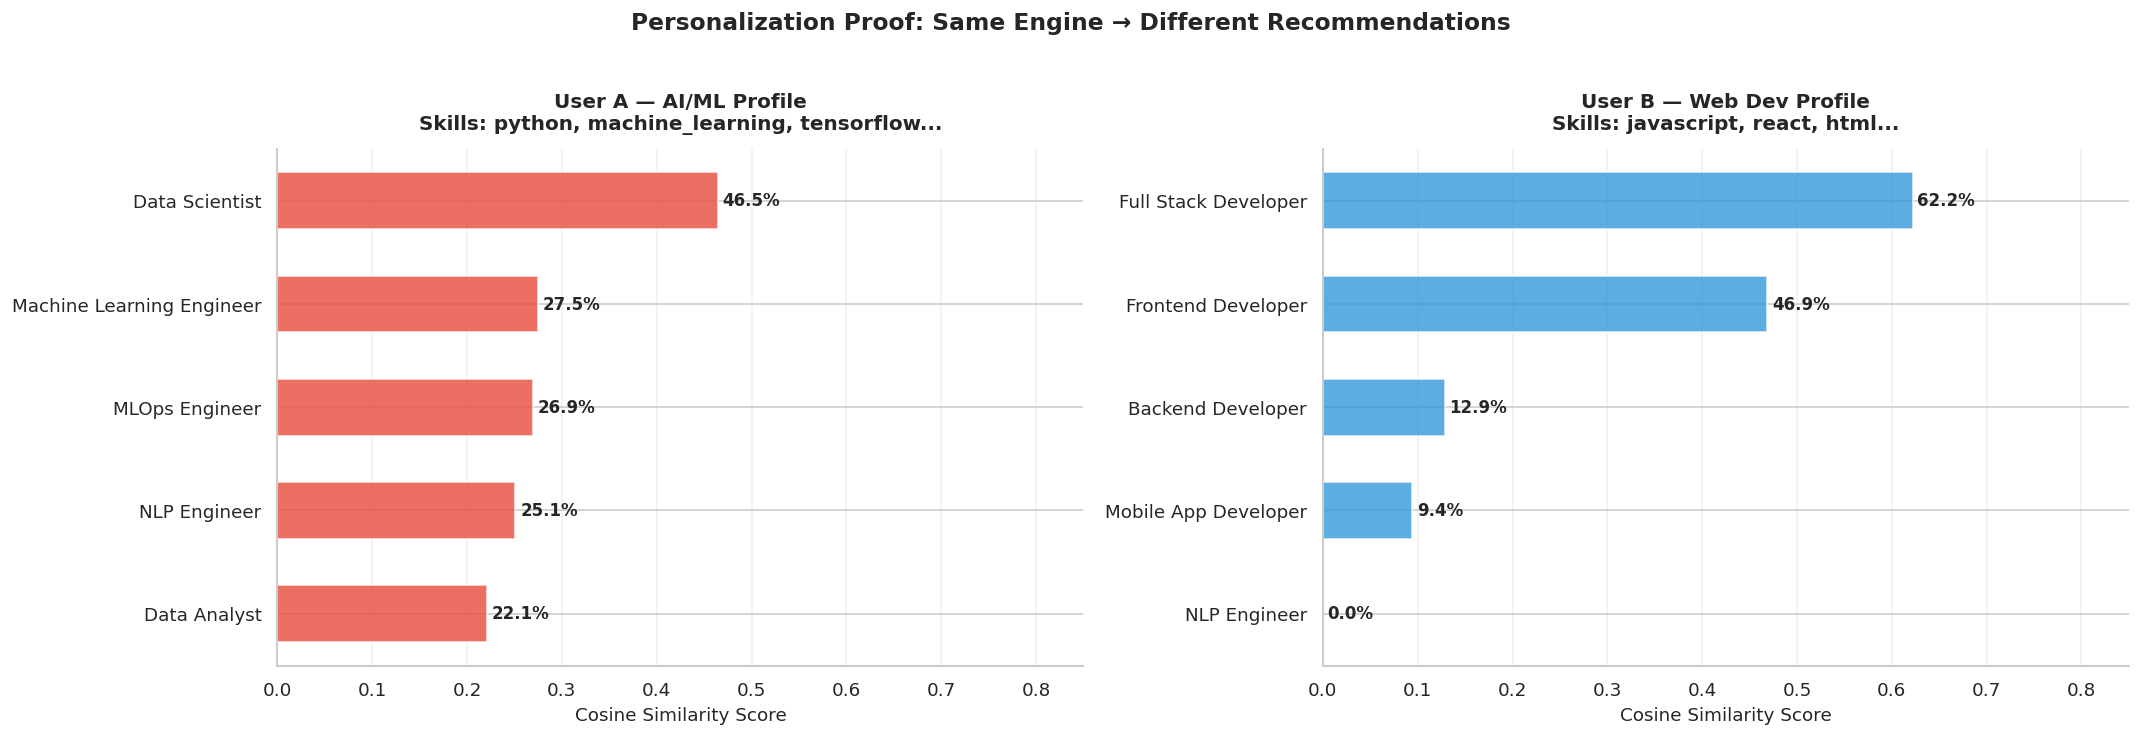


 Same engine, completely different outputs.
 This is content-based personalization in action.


In [14]:
# TWO-USER SIDE-BY-SIDE COMPARISON

user_a_skills = ["python", "machine_learning", "tensorflow", "data_analysis"]
user_b_skills = ["javascript", "react", "html", "css", "nodejs"]

recs_a = get_recommendations(user_a_skills, top_n=5)
recs_b = get_recommendations(user_b_skills, top_n=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for ax, recs, user_label, skills, color in [
    (ax1, recs_a, "User A — AI/ML Profile",   user_a_skills, "#E74C3C"),
    (ax2, recs_b, "User B — Web Dev Profile",  user_b_skills, "#3498DB"),
]:
    roles  = recs["Job Role"].tolist()
    scores = recs["similarity_score"].tolist()

    bars = ax.barh(
        roles[::-1], scores[::-1],
        color=color, alpha=0.8,
        height=0.55, edgecolor="white"
    )

    for bar, score in zip(bars, scores[::-1]):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{score*100:.1f}%",
            va="center", fontsize=10, fontweight="bold"
        )

    ax.set_title(
        f"{user_label}\nSkills: {', '.join(skills[:3])}...",
        fontsize=12, fontweight="bold", pad=12
    )
    ax.set_xlabel("Cosine Similarity Score", fontsize=11)
    ax.set_xlim(0, 0.85)
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle(
    "Personalization Proof: Same Engine → Different Recommendations",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n Same engine, completely different outputs.")
print(" This is content-based personalization in action.")

  PERSONAL CAREER RECOMMENDATION FOR KASHAF

  Based on your 7 skills:
    ✦ Python
    ✦ Machine Learning
    ✦ Deep Learning
    ✦ Sql
    ✦ Data Analysis
    ✦ Git
    ✦ Tensorflow

  YOUR TOP CAREER MATCHES:

  🥇  Data Scientist
      Match  : 52.7%
      Salary : PKR 150,000–250,000/month
      Field  : Data & AI

  🥈  Machine Learning Engineer
      Match  : 29.8%
      Salary : PKR 180,000–300,000/month
      Field  : Data & AI

  🥉  MLOps Engineer
      Match  : 28.0%
      Salary : PKR 160,000–290,000/month
      Field  : Infrastructure

  4️⃣   NLP Engineer
      Match  : 27.2%
      Salary : PKR 150,000–280,000/month
      Field  : Specialized AI

  5️⃣   Data Analyst
      Match  : 24.7%
      Salary : PKR 80,000–150,000/month
      Field  : Data & AI

  SKILL GAP ANALYSIS: Data Scientist

  Skills Required   : 13
  Skills You Have   : 6
  Coverage          : 46.2%

  MATCHED SKILLS (6):
     • Data Analysis
     • Deep Learning
     • Machine Learning
     • Python
     • 

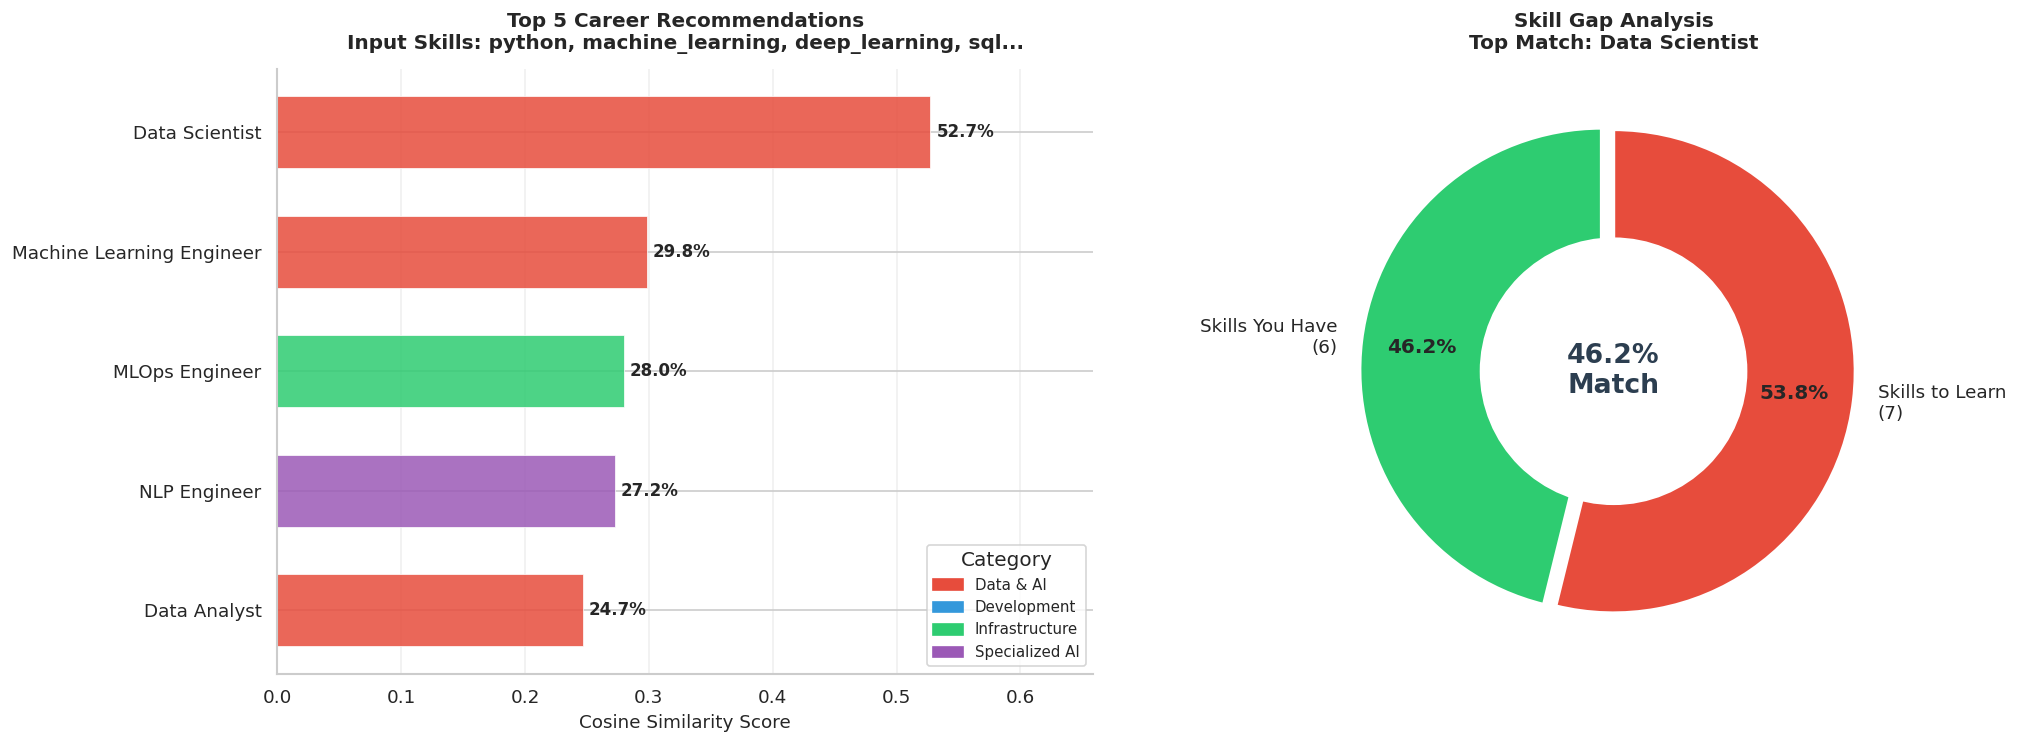

In [15]:
#  YOUR PERSONAL SKILL PROFILE

#  ENTER YOUR REAL SKILLS BELOW
YOUR_NAME   = "Kashaf"        # ← Your name
YOUR_SKILLS = [
    "python",
    "machine_learning",
    "deep_learning",
    "sql",
    "data_analysis",
    "git",
    "tensorflow",
]

print("=" * 60)
print(f"  PERSONAL CAREER RECOMMENDATION FOR {YOUR_NAME.upper()}")
print("=" * 60)

# Run recommendations
my_results = get_recommendations(YOUR_SKILLS, top_n=5)

# Display
print(f"\n  Based on your {len(YOUR_SKILLS)} skills:")
for s in YOUR_SKILLS:
    print(f"    ✦ {s.replace('_',' ').title()}")

print(f"\n  YOUR TOP CAREER MATCHES:\n")
for rank, (_, row) in enumerate(my_results.iterrows(), 1):
    medal = ["🥇","🥈","🥉","4️⃣ ","5️⃣ "][rank-1]
    print(f"  {medal}  {row['Job Role']}")
    print(f"      Match  : {row['match_pct']}")
    print(f"      Salary : {row['avg_salary']}")
    print(f"      Field  : {row['category']}\n")

# Skill gap for your #1 match
top = my_results.iloc[0]["Job Role"]
my_gap = analyze_skill_gap(YOUR_SKILLS, top)
display_skill_gap(my_gap)

# Full visualization
visualize_recommendations(my_results, YOUR_SKILLS, my_gap)